# Exercise 1: Efficiently search patient data (25 points)

### 1a. Plot Age Distribution

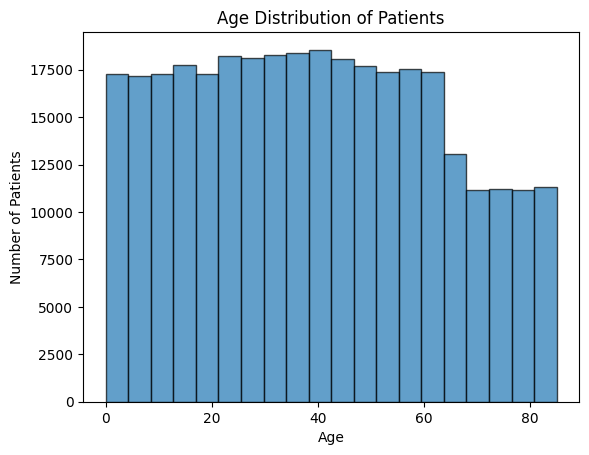

Patients with the same age: []
Do multiple patients share the same age? False


In [12]:
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
from collections import Counter

# Load and parse the XML file
xml_file_path = '/Users/luischan/Downloads/hw1-patients.xml'  
tree = ET.parse(xml_file_path)
root = tree.getroot()

# Extract patient data (age, gender, name)
patients = []
for patient in root.findall('.//patient'):
    age = float(patient.get('age'))
    gender = patient.get('gender')
    name = patient.get('name')
    patients.append({'age': age, 'gender': gender, 'name': name})

# Task 1a: Plot Age Distribution
ages = [patient['age'] for patient in patients]

# Plotting the histogram for Age Distribution
plt.hist(ages, bins=20, edgecolor='black', alpha=0.7)
plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.show()

# Check for any patients with the same exact age
age_counts = Counter(ages)
same_age_patients = [age for age, count in age_counts.items() if count > 1]

# Extra Credit: Identify if multiple patients share the same age
multiple_age_patients = len(same_age_patients) > 0

# Output
print("Patients with the same age:", same_age_patients[:10])
print("Do multiple patients share the same age?", multiple_age_patients)


### 1b. Plot Gender Distribution

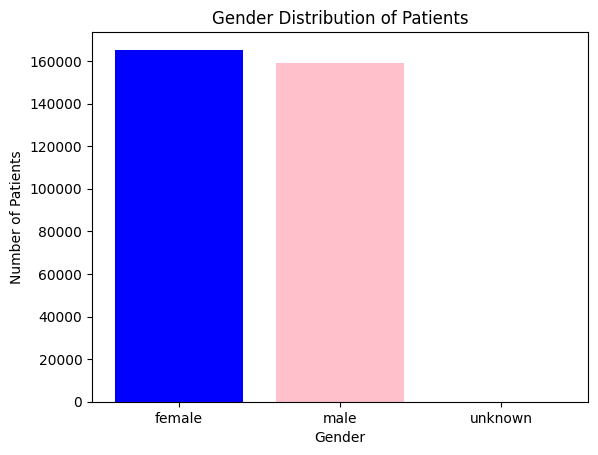

Gender Counts: Counter({'female': 165293, 'male': 158992, 'unknown': 72})
Gender Categories: ['female', 'male', 'unknown']


In [13]:
import matplotlib.pyplot as plt
from collections import Counter

# Extract the gender data
genders = [patient['gender'] for patient in patients if patient['gender']]

# Plotting the distribution of genders
gender_counts = Counter(genders)

# Plotting a bar chart for gender distribution
plt.bar(gender_counts.keys(), gender_counts.values(), color=['blue', 'pink'])
plt.title("Gender Distribution of Patients")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")
plt.show()

# List the categories used in gender encoding
gender_categories = list(gender_counts.keys())
print("Gender Counts:", gender_counts)
print("Gender Categories:", gender_categories)

### 1c. Sort Patients by Age

In [14]:
# Sorting patients by age
sorted_patients = sorted(patients, key=lambda x: x['age'])

# Identify the oldest patient
oldest_patient = sorted_patients[-1]

# Output the oldest patient's details
print("Oldest Patient:", oldest_patient)


Oldest Patient: {'age': 84.99855742449432, 'gender': 'female', 'name': 'Monica Caponera'}


### 1d. Finding the Second Oldest Patient

In [15]:
def find_second_oldest(patients):
    oldest = second_oldest = None

    for patient in patients:
        age = patient['age']
        if oldest is None or age > oldest:
            second_oldest = oldest
            oldest = age
        elif second_oldest is None or age > second_oldest:
            second_oldest = age

    return second_oldest


Scenarios Where Sorting is Advantageous:
Multiple Queries: Sorting helps when you need to repeatedly find the oldest, second oldest, or other values, since accessing sorted data is O(1) after the initial sort.
Efficient Range Queries: A sorted list allows for efficient age range queries and binary search, which are faster (O(log n)) compared to scanning an unsorted list.
Preprocessing: If you're doing many different queries on the same dataset, sorting once (O(n log n)) can save time overall.
In contrast, the O(n) solution is preferable when you only need to find the second oldest patient once, as it avoids the overhead of sorting.

### 1e. Binary Search for Specific Age 

In [16]:
from bisect import bisect_left

def binary_search_age(patients, target_age):
    # List of ages for binary search
    ages = [patient['age'] for patient in patients]
    
    # Perform binary search
    index = bisect_left(ages, target_age)
    
    # Check if the target age is found
    if index < len(ages) and ages[index] == target_age:
        return patients[index]  # Return the patient with the exact age
    else:
        return None  # If no patient is found with the exact age

# Sorted patient list (from the previous step)
patient_41_5 = binary_search_age(sorted_patients, 41.5)

print(patient_41_5)


{'age': 41.5, 'gender': 'male', 'name': 'John Braswell'}


### 1f. Count Patients Above a Certain Age

In [17]:
from bisect import bisect_left

def count_patients_above_age(patients, target_age):
    # List of ages for binary search
    ages = [patient['age'] for patient in patients]
    
    # Find the index where target_age should be inserted
    index = bisect_left(ages, target_age)
    
    # Count how many patients are at or above the target age
    return len(patients) - index

# Count patients who are at least 41.5 years old
count_above_41_5 = count_patients_above_age(sorted_patients, 41.5)

count_above_41_5


150471

### 1g. Function for Age Range Query

In [18]:
from bisect import bisect_left, bisect_right

def count_patients_in_age_range(patients, low_age, high_age):
    # List of ages for binary search
    ages = [patient['age'] for patient in patients]
    
    # Find the index where patients are at least low_age
    low_index = bisect_left(ages, low_age)
    
    # Find the index where patients are strictly less than high_age
    high_index = bisect_left(ages, high_age)  # high_age is exclusive
    
    # Count the number of patients within the range
    return high_index - low_index

# Test the function with an example range (30 to 50 years)
age_range_count = count_patients_in_age_range(sorted_patients, 30, 50)

print(f"Number of patients aged between 30 and 50: {age_range_count}")


Number of patients aged between 30 and 50: 85714


### 1h. Function for Age and Gender Range Query

In [19]:
from bisect import bisect_left

def count_patients_in_age_gender_range(patients, low_age, high_age, gender='male'):
    # List of ages for binary search
    ages = [patient['age'] for patient in patients]
    
    # Find the index where patients are at least low_age
    low_index = bisect_left(ages, low_age)
    
    # Find the index where patients are strictly less than high_age
    high_index = bisect_left(ages, high_age)
    
    # Count patients in the range who match the gender
    gender_count = sum(1 for patient in patients[low_index:high_index] if patient['gender'] == gender)
    
    return gender_count

# Test the function with an example range (30 to 50 years, for male patients)
male_patients_in_range = count_patients_in_age_gender_range(sorted_patients, 30, 50, 'male')

print(f"Number of male patients aged between 30 and 50: {male_patients_in_range}")

Number of male patients aged between 30 and 50: 42479
